In [ ]:
import pandas as pd
from entsoe import EntsoePandasClient
import matplotlib.pyplot as plt

API_KEY="YOUR_API_KEY"
client=EntsoePandasClient(api_key=API_KEY)


start=pd.Timestamp("2022-08-01", tz="Europe/Athens")
end=pd.Timestamp("2026-08-01", tz="Europe/Athens")

country="GR"

In [3]:
prices=client.query_day_ahead_prices(country, start=start, end=end)


prices=prices.to_frame(name="price_eur_mwh")
prices = prices.resample("h").mean()

print(prices.shape)
prices.head()

(35065, 1)


,price_eur_mwh
2022-08-01 00:00:00+03:00,428.67
2022-08-01 01:00:00+03:00,429.66
2022-08-01 02:00:00+03:00,394.93
2022-08-01 03:00:00+03:00,351.51
2022-08-01 04:00:00+03:00,320.86


In [4]:
load=client.query_load(country, start=start, end=end)

load.columns=["load_mw"]




load=load.resample("h").mean()
print(load.shape)
load.head()

(35064, 1)


,load_mw
2022-08-01 00:00:00+03:00,6511.0
2022-08-01 01:00:00+03:00,6133.0
2022-08-01 02:00:00+03:00,5801.0
2022-08-01 03:00:00+03:00,5622.0
2022-08-01 04:00:00+03:00,5534.0


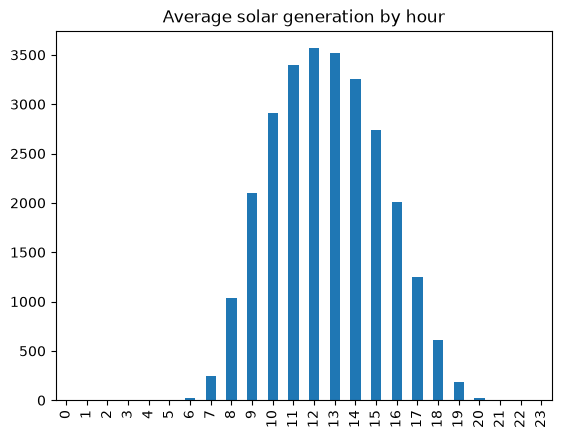

In [5]:
gen = client.query_generation(country, start=start, end=end)


gen_cols = ['Solar', 'Wind Onshore', 'Fossil Gas', 'Fossil Brown coal/Lignite', 
            'Hydro Water Reservoir', 'Fossil Oil']

gen = gen[[col for col in gen_cols if col in gen.columns]]
gen = gen.resample('h').mean()



hourly_solar = gen['Solar'].groupby(gen.index.hour).mean()
hourly_solar.plot(kind='bar', title='Average solar generation by hour')
plt.show()

In [6]:
neighbors = {'BG': 'Bulgaria', 'IT': 'Italy', 'MK': 'North Macedonia'}
flows = pd.DataFrame()

for code in neighbors:
    imports = client.query_crossborder_flows(code, country, start=start, end=end)
    exports = client.query_crossborder_flows(country, code, start=start, end=end)
    net = imports.resample('h').mean() - exports.resample('h').mean()
    flows[f'net_import_{code.lower()}'] = net.tz_convert('Europe/Athens')

print(flows.shape)
flows.head()

(35064, 3)


,net_import_bg,net_import_it,net_import_mk
2022-08-01 00:00:00+03:00,336.0,-509.0,226.0
2022-08-01 01:00:00+03:00,275.0,-509.0,21.0
2022-08-01 02:00:00+03:00,295.0,-509.0,38.0
2022-08-01 03:00:00+03:00,307.0,-509.0,77.0
2022-08-01 04:00:00+03:00,297.0,-509.0,83.0


In [7]:
import yfinance as yf

ttf=yf.download("TTF=F",start=start, end=end)
ttf=ttf[["Close"]].rename(columns={"Close":"ttf_eur_mwh"})

print(ttf.shape)
ttf.head()

[*********************100%***********************]  1 of 1 completed

(1006, 1)


Price,ttf_eur_mwh
Ticker,TTF=F
Date,
2022-08-01,200.794006
2022-08-02,205.173996
2022-08-03,199.195007
2022-08-04,199.248001
2022-08-05,196.320007


In [8]:
import os

os.makedirs("../data", exist_ok=True)


prices.to_csv("../data/prices.csv")
load.to_csv("../data/load.csv")
gen.to_csv("../data/generation.csv")
flows.to_csv("../data/flows.csv")
ttf.to_csv("../data/ttf.csv")
print(" All five datasets exported")

 All five datasets exported


In [9]:
flows.to_csv("../data/flows.csv")

In [10]:
import sqlite3
import pandas as pd

conn=sqlite3.connect("../energy.db")
cursor=conn.cursor()

print("Connected to energy.db")

Connected to energy.db


In [11]:
prices=pd.read_csv("../data/prices.csv",index_col=0)
load=pd.read_csv("../data/load.csv",index_col=0)
generation=pd.read_csv("../data/generation.csv",index_col=0)
flows=pd.read_csv("../data/flows.csv",index_col=0)  
ttf=pd.read_csv("../data/ttf.csv",index_col=0)  

prices.to_sql("prices",conn,if_exists="replace")
load.to_sql("load",conn,if_exists="replace")
generation.to_sql("generation",conn,if_exists="replace")
flows.to_sql("flows",conn,if_exists="replace")
ttf.to_sql("ttf",conn,if_exists="replace")

print("All tables loaded into SQLite")



All tables loaded into SQLite


In [12]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables=cursor.fetchall()
print("Tables in database:")
for table in tables:
    print(f"-{table[0]}")


for table in tables:
    print(f"\n{table[0]}")
    cursor.execute(f"PRAGMA table_info({table[0]});")
    columns=cursor.fetchall()
    for col in columns:
        print(f" {col[1]} ({col[2]})")



Tables in database:
-prices
-load
-generation
-flows
-ttf

prices
 index (TEXT)
 price_eur_mwh (REAL)

load
 index (TEXT)
 load_mw (REAL)

generation
 index (TEXT)
 Solar (REAL)
 Wind Onshore (REAL)
 Fossil Gas (REAL)
 Fossil Brown coal/Lignite (REAL)
 Hydro Water Reservoir (REAL)
 Fossil Oil (REAL)

flows
 index (TEXT)
 net_import_bg (REAL)
 net_import_it (REAL)
 net_import_mk (REAL)

ttf
 Price (TEXT)
 ttf_eur_mwh (TEXT)


In [13]:
for table in ["prices","load","generation","flows","ttf"]:
    cursor.execute(f"SELECT COUNT(*) FROM {table};")
    count=cursor.fetchone()[0]
    print(f"{table}: {count} rows")

print("\nFirst 5 prices:")
df=pd.read_sql("SELECT * FROM prices LIMIT 5;", conn)
print(df)

print("\nFirst 5 generation:")
df=pd.read_sql("SELECT * FROM generation LIMIT 5;", conn)
print(df)


prices: 35065 rows
load: 35064 rows
generation: 35064 rows
flows: 35064 rows
ttf: 1008 rows

First 5 prices:
                       index  price_eur_mwh
0  2022-08-01 00:00:00+03:00         428.67
1  2022-08-01 01:00:00+03:00         429.66
2  2022-08-01 02:00:00+03:00         394.93
3  2022-08-01 03:00:00+03:00         351.51
4  2022-08-01 04:00:00+03:00         320.86

First 5 generation:
                       index  Solar  Wind Onshore  Fossil Gas  \
0  2022-08-01 00:00:00+03:00    0.0         541.0      3922.0   
1  2022-08-01 01:00:00+03:00    0.0         588.0      4193.0   
2  2022-08-01 02:00:00+03:00    0.0         700.0      3706.0   
3  2022-08-01 03:00:00+03:00    0.0         895.0      3360.0   
4  2022-08-01 04:00:00+03:00    0.0        1087.0      3180.0   

   Fossil Brown coal/Lignite  Hydro Water Reservoir  Fossil Oil  
0                     1113.0                  509.0         0.0  
1                     1137.0                  294.0         0.0  
2                

In [14]:
query="""
SELECT
    strftime("%H","index") as hour,
    ROUND(AVG(price_eur_mwh),2) as avg_price
FROM prices
GROUP BY strftime ("%H","index")
ORDER BY hour;
"""
result=pd.read_sql(query,conn)
print(result)

   hour  avg_price
0    00     114.20
1    01     109.86
2    02     109.42
3    03     117.23
4    04     132.68
5    05     143.07
6    06     133.13
7    07     112.55
8    08      95.64
9    09      85.43
10   10      81.64
11   11      81.38
12   12      86.19
13   13     101.69
14   14     126.29
15   15     157.86
16   16     185.38
17   17     204.70
18   18     198.36
19   19     168.73
20   20     147.38
21   21     135.09
22   22     125.34
23   23     118.93


In [15]:
###NULL COUNT to see whether the data is ok


cursor.execute("""
SELECT
    "Solar" as column_name,
    COUNT(*) as total_rows,
    SUM(CASE WHEN solar IS NULL THEN 1 ELSE 0 END) as null_count
FROM generation
UNION ALL
SELECT "Wind Onshore",COUNT(*),SUM(CASE WHEN "Wind Onshore" IS NULL THEN 1 ELSE 0 END) FROM generation
UNION ALL
SELECT "Fossil Gas", COUNT(*),SUM(CASE WHEN "Fossil Gas" IS NULL THEN 1 ELSE 0 END) FROM generation;
""")   

results=cursor.fetchall()
for row in results:
    print(f"{row[0]}: {row[2]} NULLs out of {row[1]} rows")




0.0: 8768 NULLs out of 35064 rows
541.0: 8768 NULLs out of 35064 rows
3922.0: 8770 NULLs out of 35064 rows


In [16]:
query=""" 
SELECT
    strftime("%H","index") as hour,
    ROUND(AVG(price_eur_mwh), 2) as avg_price
FROM prices
GROUP BY strftime("%H","index")
ORDER BY hour;
"""

result=pd.read_sql(query,conn)
print(result)

   hour  avg_price
0    00     114.20
1    01     109.86
2    02     109.42
3    03     117.23
4    04     132.68
5    05     143.07
6    06     133.13
7    07     112.55
8    08      95.64
9    09      85.43
10   10      81.64
11   11      81.38
12   12      86.19
13   13     101.69
14   14     126.29
15   15     157.86
16   16     185.38
17   17     204.70
18   18     198.36
19   19     168.73
20   20     147.38
21   21     135.09
22   22     125.34
23   23     118.93


In [17]:
query=""" 
SELECT
    strftime("%H",p."index") as hour,
    ROUND(AVG(p.price_eur_mwh),2) as avg_price,
    ROUND(AVG(g.Solar),0) as avg_solar_mw,
    ROUND(AVG(g."Wind Onshore"),0) as avg_wind_mw,
    ROUND(AVG(g."Fossil Gas"),0) as avg_gas_mw
FROM prices p
JOIN generation g ON p."index"=g."index"
GROUP BY strftime("%H",p."index")
ORDER BY hour;
"""
result=pd.read_sql(query,conn)
print(result)

   hour  avg_price  avg_solar_mw  avg_wind_mw  avg_gas_mw
0    00     114.20           0.0       1181.0      1960.0
1    01     109.86           0.0       1194.0      1879.0
2    02     109.42           3.0       1210.0      1859.0
3    03     117.23          21.0       1223.0      1915.0
4    04     132.68         192.0       1218.0      2052.0
5    05     143.07         758.0       1185.0      2119.0
6    06     133.13        1687.0       1143.0      2013.0
7    07     112.55        2607.0       1098.0      1790.0
8    08      95.64        3230.0       1058.0      1590.0
9    09      85.43        3521.0       1040.0      1488.0
10   10      81.64        3578.0       1052.0      1486.0
11   11      81.38        3422.0       1068.0      1516.0
12   12      86.19        3028.0       1088.0      1590.0
13   13     101.69        2395.0       1117.0      1812.0
14   14     126.29        1526.0       1147.0      2200.0
15   15     157.86         687.0       1162.0      2631.0
16   16     18

In [18]:
query = """
SELECT 
    p."index" as timestamp,
    p.price_eur_mwh as price,
    g.Solar as solar_mw,
    g."Wind Onshore" as wind_mw,
    g."Fossil Gas" as gas_mw
FROM prices p
JOIN generation g ON p."index" = g."index"
WHERE p.price_eur_mwh > 200
ORDER BY p.price_eur_mwh DESC
LIMIT 20;
"""

result = pd.read_sql(query, conn)
print(result)

                    timestamp   price  solar_mw  wind_mw  gas_mw
0   2024-09-04 20:00:00+03:00  942.00       0.0    279.0  4318.0
1   2022-08-30 20:00:00+03:00  936.33       0.0    348.0  3230.0
2   2022-08-31 20:00:00+03:00  918.55       0.0    254.0  2917.0
3   2024-09-03 20:00:00+03:00  911.00       0.0    178.0  4404.0
4   2022-08-31 21:00:00+03:00  907.82       0.0    282.0  2929.0
5   2022-08-30 19:00:00+03:00  894.76      79.0    436.0  3245.0
6   2022-08-30 21:00:00+03:00  892.27       0.0    400.0  3236.0
7   2022-08-29 20:00:00+03:00  871.00       0.0    276.0  3277.0
8   2022-08-31 19:00:00+03:00  871.00      84.0    222.0  2840.0
9   2024-07-22 21:00:00+03:00  850.00       0.0    600.0  4577.0
10  2022-08-29 19:00:00+03:00  837.89      88.0    284.0  3189.0
11  2022-08-29 21:00:00+03:00  833.74       0.0    256.0  3330.0
12  2022-08-30 22:00:00+03:00  829.84       0.0    498.0  2956.0
13  2022-08-31 18:00:00+03:00  822.35     470.0    276.0  2890.0
14  2022-08-30 18:00:00+0

In [19]:
query = """
SELECT 
    p."index" as timestamp,
    p.price_eur_mwh as price,
    g.Solar as solar_mw,
    g."Wind Onshore" as wind_mw
FROM prices p
JOIN generation g ON p."index" = g."index"
WHERE p.price_eur_mwh < 0
ORDER BY p.price_eur_mwh ASC
LIMIT 20;
"""

result = pd.read_sql(query, conn)
print(result)
print(f"\nTotal negative price hours: {len(result)}")

                    timestamp    price  solar_mw  wind_mw
0   2025-05-01 14:00:00+03:00 -50.0000     749.0    708.0
1   2025-05-01 15:00:00+03:00 -50.0000     646.0    601.0
2   2026-04-05 14:00:00+03:00 -50.0000       NaN      NaN
3   2026-04-05 15:00:00+03:00 -50.0000       NaN      NaN
4   2026-04-25 14:00:00+03:00 -50.0000       NaN      NaN
5   2026-04-25 15:00:00+03:00 -50.0000       NaN      NaN
6   2026-04-25 16:00:00+03:00 -50.0000       NaN      NaN
7   2026-04-26 12:00:00+03:00 -50.0000       NaN      NaN
8   2026-04-26 13:00:00+03:00 -50.0000       NaN      NaN
9   2026-04-25 13:00:00+03:00 -48.9225       NaN      NaN
10  2026-04-05 16:00:00+03:00 -47.4700       NaN      NaN
11  2026-04-05 13:00:00+03:00 -35.7825       NaN      NaN
12  2026-04-05 12:00:00+03:00 -35.4550       NaN      NaN
13  2026-04-25 12:00:00+03:00 -35.0075       NaN      NaN
14  2026-04-26 11:00:00+03:00 -28.1625       NaN      NaN
15  2026-04-26 14:00:00+03:00 -25.4950       NaN      NaN
16  2025-05-01

In [20]:
####MASTER DATA SHEET
query=""" 
SELECT
    p."index" as datetime,
    p.price_eur_mwh as price,
    l.load_mw as load,
    g.Solar as solar,
    g."Wind Onshore" as wind,
    g."Fossil Gas" as gas,
    g."Fossil Brown coal/Lignite" as lignite,
    g."Hydro Water Reservoir" as hydro,
    f.net_import_bg,
    f.net_import_it,
    f.net_import_mk,
    strftime("%H",p."index") as hour,
    strftime("%w",p."index") as day_of_week,
    strftime("%m",p."index") as month
FROM prices p 
LEFT JOIN load l ON p."index"=l."index"
LEFT JOIN generation g ON p."index"=g."index"
LEFT JOIN flows f ON p."index"=f."index" 
ORDER BY p."index";
 """

analysis_data=pd.read_sql(query,conn)
print(f"shape: {analysis_data.shape}")
print(analysis_data.head())

analysis_data.to_csv("../data/analysis_dataset.csv", index=False)
print("Analysis dataset exported")

shape: (35065, 14)
                    datetime   price    load  solar    wind     gas  lignite  \
0  2022-08-01 00:00:00+03:00  428.67  6511.0    0.0   541.0  3922.0   1113.0   
1  2022-08-01 01:00:00+03:00  429.66  6133.0    0.0   588.0  4193.0   1137.0   
2  2022-08-01 02:00:00+03:00  394.93  5801.0    0.0   700.0  3706.0   1144.0   
3  2022-08-01 03:00:00+03:00  351.51  5622.0    0.0   895.0  3360.0   1120.0   
4  2022-08-01 04:00:00+03:00  320.86  5534.0    0.0  1087.0  3180.0   1148.0   

   hydro  net_import_bg  net_import_it  net_import_mk hour day_of_week month  
0  509.0          336.0         -509.0          226.0   21           0    07  
1  294.0          275.0         -509.0           21.0   22           0    07  
2  280.0          295.0         -509.0           38.0   23           0    07  
3  172.0          307.0         -509.0           77.0   00           1    08  
4  171.0          297.0         -509.0           83.0   01           1    08  
Analysis dataset exported


In [21]:
# Read the flows CSV and inspect it
flows = pd.read_csv('../data/flows.csv', index_col=0)

print("Flows shape:", flows.shape)
print("Flows columns:", flows.columns.tolist())
print("\nFirst 5 rows:")
print(flows.head())

Flows shape: (35064, 3)
Flows columns: ['net_import_bg', 'net_import_it', 'net_import_mk']

First 5 rows:
                           net_import_bg  net_import_it  net_import_mk
2022-08-01 00:00:00+03:00          336.0         -509.0          226.0
2022-08-01 01:00:00+03:00          275.0         -509.0           21.0
2022-08-01 02:00:00+03:00          295.0         -509.0           38.0
2022-08-01 03:00:00+03:00          307.0         -509.0           77.0
2022-08-01 04:00:00+03:00          297.0         -509.0           83.0
